In [12]:
import os
os.chdir(r'C:\Users\Klara\retail-intelligence')
print("Working directory:", os.getcwd())

Working directory: C:\Users\Klara\retail-intelligence


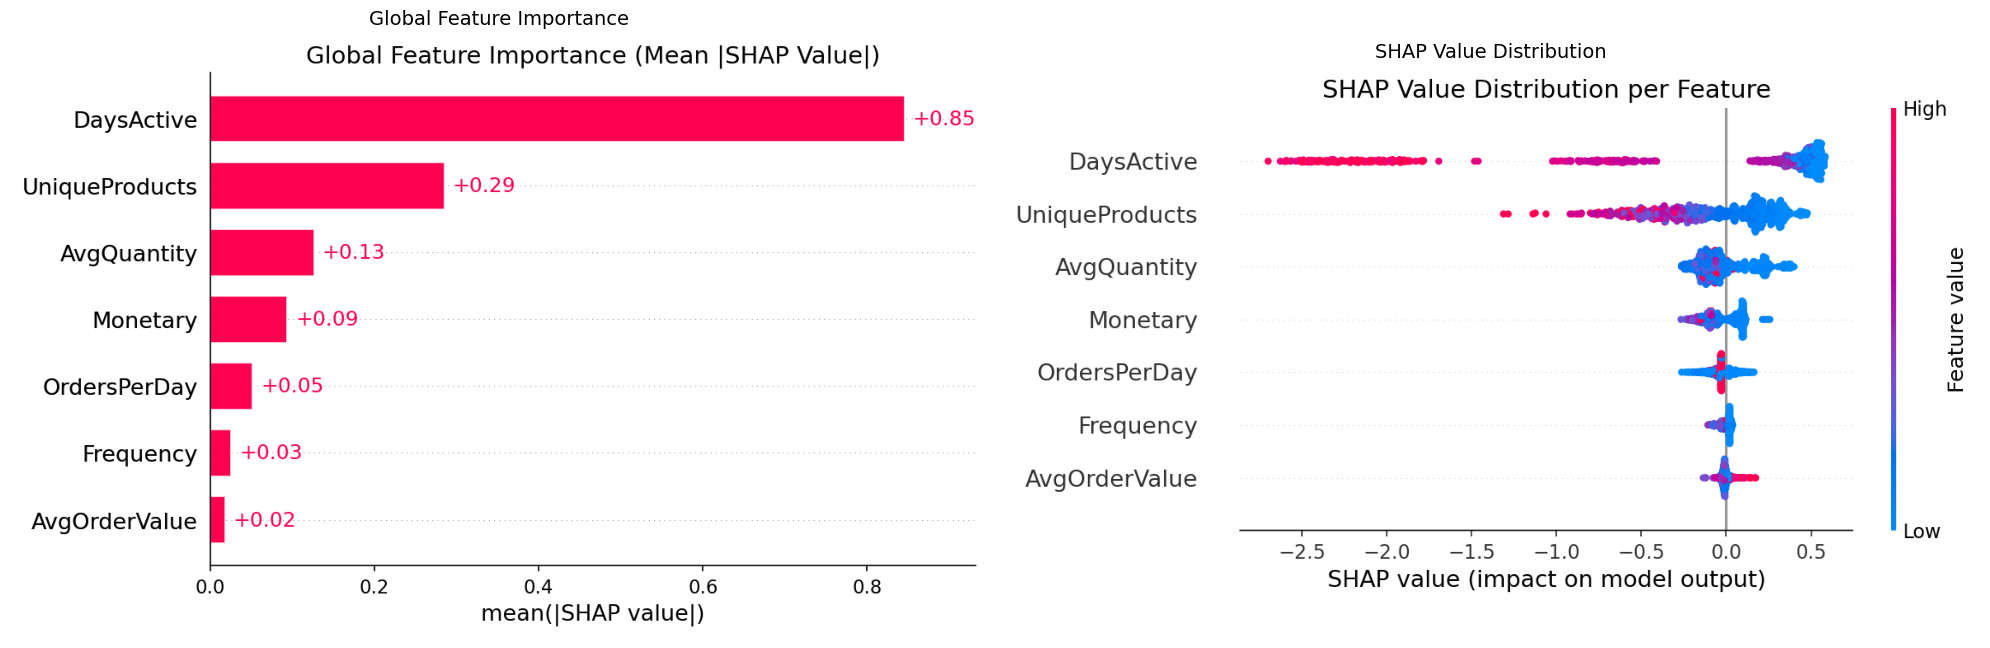

          Feature  MeanAbsSHAP  Rank
0      DaysActive     0.845666     1
1  UniqueProducts     0.285118     2
2     AvgQuantity     0.126729     3
3        Monetary     0.093819     4
4    OrdersPerDay     0.051956     5
5       Frequency     0.025554     6
6   AvgOrderValue     0.018269     7


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

bar = mpimg.imread('notebooks/shap_plots/global_bar.png')
beeswarm = mpimg.imread('notebooks/shap_plots/global_beeswarm.png')

axes[0].imshow(bar)
axes[0].axis('off')
axes[0].set_title('Global Feature Importance', fontsize=14)

axes[1].imshow(beeswarm)
axes[1].axis('off')
axes[1].set_title('SHAP Value Distribution', fontsize=14)

plt.tight_layout()
plt.show()

importance = pd.read_csv('data/processed/feature_importance.csv')
print(importance)

In [14]:
import sys
sys.path.append('..')
from src.module1_churn.data_preparation import prepare_churn_data

data = prepare_churn_data()
X_test = data['X_test']

print(X_test['Frequency'].describe())
print()

X_test.corr()

Loading data...

📊 Data preparation complete:
   Training set: 3,136 customers
   Test set: 784 customers
   Features: 7

   Training churn rate: 33.4%
   Test churn rate: 33.3%
count    784.000000
mean       4.487245
std        9.335377
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max      209.000000
Name: Frequency, dtype: float64



,Frequency,Monetary,AvgOrderValue,UniqueProducts,AvgQuantity,DaysActive,OrdersPerDay
Frequency,1.000000,0.653381,0.032412,0.738869,0.022323,0.427432,-0.211451
Monetary,0.653381,1.000000,0.439276,0.347085,0.270656,0.363084,-0.185567
AvgOrderValue,0.032412,0.439276,1.000000,0.064233,0.636008,0.043048,-0.049241
UniqueProducts,0.738869,0.347085,0.064233,1.000000,-0.078683,0.428620,-0.249769
AvgQuantity,0.022323,0.270656,0.636008,-0.078683,1.000000,0.030962,-0.044096
DaysActive,0.427432,0.363084,0.043048,0.428620,0.030962,1.000000,-0.712404
OrdersPerDay,-0.211451,-0.185567,-0.049241,-0.249769,-0.044096,-0.712404,1.000000


## SHAP Global Feature Importance — Observations

**1. Most important driver of churn**

`DaysActive` is by far the strongest driver, with mean |SHAP value| = 0.846 — nearly 3x higher than #2 (`UniqueProducts` at 0.285). One feature is doing most of the work here.

**2. Direction of DaysActive**

In the beeswarm, high `DaysActive` (pink dots) clusters left (-2.5 to -1.0), low `DaysActive` (blue dots) clusters right (0 to +0.5). Left = away from churn, right = toward churn. So:

**High DaysActive → lower churn risk. Low DaysActive → higher churn risk.**

Makes sense — longer-tenured customers are stickier.

**3. Direction of Frequency**

Dots are tightly bunched near 0, almost no spread — barely any influence on individual predictions. Matches its low rank (6th of 7, mean |SHAP| = 0.026).

**4. Surprising result + investigation**

`Frequency` and `AvgOrderValue` ranked dead last (6th and 7th of 7) despite being classic RFM churn signals — surprising enough to check rather than just note.

Two possible causes: (a) the feature is broken/uninformative, or (b) it's real but overshadowed by a correlated feature.

- **Variance check** (rules out a): `Frequency` ranges 1–209, std ≈ 9.3 — real spread, not constant/broken.
- **Correlation check** (tests b): `Frequency` correlates 0.739 with `UniqueProducts`, which ranked #2.

**Conclusion**: cause (b), not a bug. `UniqueProducts` carries overlapping information, and XGBoost's trees split on it preferentially, leaving little independent signal for `Frequency` to add. This is known behavior with correlated features in tree-based SHAP — importance gets absorbed by whichever correlated feature the trees lean on first, even if the raw feature is genuinely informative alone. Worth stating explicitly, since conflating "low SHAP importance" with "the feature doesn't matter" is a common misread.